In [23]:
import xgboost as xgb
%pip install matplotlib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_sample_weight
%pip install seaborn
import seaborn as sns



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import numpy as np

In [26]:
edstays = pd.read_csv("data/mimic-iv-ed-2.2/ed/edstays.csv.gz")
triage = pd.read_csv("data/mimic-iv-ed-2.2/ed/triage.csv.gz")
vitals = pd.read_csv("data/mimic-iv-ed-2.2/ed/vitalsign.csv.gz")
medrecon = pd.read_csv("data/mimic-iv-ed-2.2/ed/medrecon.csv.gz")
pyxis = pd.read_csv("data/mimic-iv-ed-2.2/ed/pyxis.csv.gz")
diagnosis = pd.read_csv("data/mimic-iv-ed-2.2/ed/diagnosis.csv.gz")
erha = pd.read_csv("data/mimic-iv-ed-2.2/ed/complaint_to_erha_llm.csv")

In [27]:
print(edstays.columns)
print(triage.columns)
print(vitals.columns)
print(diagnosis.columns)
print(pyxis.columns)
print(medrecon.columns)
print(erha.columns)

Index(['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender',
       'race', 'arrival_transport', 'disposition'],
      dtype='str')
Index(['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate',
       'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp', 'rhythm', 'pain'],
      dtype='str')
Index(['subject_id', 'stay_id', 'seq_num', 'icd_code', 'icd_version',
       'icd_title'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'med_rn', 'name', 'gsn_rn',
       'gsn'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'name', 'gsn', 'ndc', 'etc_rn',
       'etccode', 'etcdescription'],
      dtype='str')
Index(['complaint', 'freq', 'erha_codes', 'erha_names', 'confidence',
       'parse_error', 'reviewed'],
      dtype='str')


In [28]:
ed_triage = edstays.merge(triage, on="stay_id", how="left")

In [29]:
vitals_first = (vitals.sort_values("charttime").groupby("stay_id").first().reset_index())

In [30]:
ed_triage = ed_triage.merge(
    vitals_first[["stay_id", "charttime", "rhythm"]],
    on="stay_id",
    how="left"
)

In [31]:
ed_triage["Chief_Complaints"] = (ed_triage["chiefcomplaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
erha["Chief_Complaints"] = (erha["complaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
triage["Chief_Complaints"] = (triage["chiefcomplaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
print(erha.columns)
print(ed_triage.columns)

Index(['complaint', 'freq', 'erha_codes', 'erha_names', 'confidence',
       'parse_error', 'reviewed', 'Chief_Complaints'],
      dtype='str')
Index(['subject_id_x', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender',
       'race', 'arrival_transport', 'disposition', 'subject_id_y',
       'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain',
       'acuity', 'chiefcomplaint', 'charttime', 'rhythm', 'Chief_Complaints'],
      dtype='str')


In [32]:
print(ed_triage.shape)
print(erha.shape)
ed_triage = ed_triage.merge(
    erha[["Chief_Complaints", "erha_codes", "erha_names"]],
    on="Chief_Complaints",
    how="left"
)

(425087, 22)
(57928, 8)


In [33]:
ed_triage.tail(2)

,subject_id_x,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition,subject_id_y,...,sbp,dbp,pain,acuity,chiefcomplaint,charttime,rhythm,Chief_Complaints,erha_codes,erha_names
425085,19999914,NaN,32002659,2158-12-24 11:41:00,2158-12-24 11:56:00,F,UNKNOWN,UNKNOWN,ELOPED,19999914,...,93.0,55.0,0,2.0,"Altered mental status, Substance use",2158-12-24 11:43:00,NaN,"altered mental status, substance use",ERHA16;ERHA53,의식장애;중독
425086,19999987,23865745.0,34731548,2145-11-02 19:28:00,2145-11-02 22:59:00,F,UNKNOWN,AMBULANCE,ADMITTED,19999987,...,NaN,NaN,NaN,NaN,HEAD BLEED,2145-11-02 19:40:00,Sinus Tachycardia,head bleed,ERHA36,그밖의출혈


In [34]:
ed_triage.loc[[0,1,2,3,4],('temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain')]

,temperature,heartrate,resprate,o2sat,sbp,dbp,pain
0,98.4,70.0,16.0,97.0,106.0,63.0,0
1,98.9,88.0,18.0,97.0,116.0,88.0,10
2,99.4,105.0,18.0,96.0,106.0,57.0,10
3,97.8,87.0,14.0,97.0,71.0,43.0,7
4,98.7,77.0,16.0,98.0,96.0,50.0,13


In [35]:
print(ed_triage["Chief_Complaints"].nunique())
print(erha["complaint"].nunique())

57927
57927


In [36]:
ed_triage.isnull().sum().sort_values(ascending=False)

rhythm               397033
hadm_id              222071
temperature           23415
o2sat                 20596
resprate              20353
dbp                   19091
sbp                   18291
heartrate             17090
charttime             16941
pain                  12933
acuity                 6987
chiefcomplaint           23
Chief_Complaints         23
intime                    0
subject_id_x              0
stay_id                   0
arrival_transport         0
race                      0
gender                    0
outtime                   0
subject_id_y              0
disposition               0
erha_codes                0
erha_names                0
dtype: int64

In [37]:
ed_triage.dtypes

subject_id_x           int64
hadm_id              float64
stay_id                int64
intime                   str
outtime                  str
gender                   str
race                     str
arrival_transport        str
disposition              str
subject_id_y           int64
temperature          float64
heartrate            float64
resprate             float64
o2sat                float64
sbp                  float64
dbp                  float64
pain                     str
acuity               float64
chiefcomplaint           str
charttime                str
rhythm                   str
Chief_Complaints         str
erha_codes               str
erha_names               str
dtype: object

In [38]:
ed_triage['pain'] = pd.to_numeric(ed_triage['pain'],errors='coerce')
ed_triage['rhythm'] = pd.to_numeric(ed_triage['rhythm'],errors='coerce')

In [39]:
ed_triage["acuity_group"] = np.nan

#ed_triage.loc[ed_triage["acuity"] == 1, "acuity_group"] = 0
#ed_triage.loc[ed_triage["acuity"] == 2, "acuity_group"] = 1
#ed_triage.loc[ed_triage["acuity"] == 3, "acuity_group"] = 2
#ed_triage.loc[ed_triage["acuity"] == 4, "acuity_group"] = 3
#ed_triage.loc[ed_triage["acuity"] == 5, "acuity_group"] = 4

ed_triage.loc[ed_triage["acuity"] < 3, "acuity_group"] = 0
ed_triage.loc[ed_triage["acuity"] == 3, "acuity_group"] = 1
ed_triage.loc[ed_triage["acuity"] > 3, "acuity_group"] = 2
ed_triage = ed_triage.dropna(subset=["acuity_group"])

In [40]:
ed_triage["stay_id"].nunique()

418100

In [41]:
ed_triage["acuity"].value_counts(dropna=False)

acuity
3.0    225066
2.0    139411
4.0     28504
1.0     24019
5.0      1100
Name: count, dtype: int64

In [42]:
def bad_high(type, limit,name):
    ed_triage[name] = (ed_triage[type].gt(limit) ).fillna(False).astype(int)
    
def normal_low(type, limit,name):
    ed_triage[name] = (ed_triage[type].lt(limit) ).fillna(False).astype(int)

    
def missing(type,name):
    ed_triage[name] = ed_triage[type].isna().astype(int)
    
def normal(type, hi_limit,low_limit,name):
    ed_triage[name] =  ((ed_triage[type].gt(low_limit) ) | (ed_triage[type].lt(hi_limit) )).fillna(False).astype(int)


def extremes(type, hi_limit,low_limit,name):
    ed_triage[name] =  ((ed_triage[type].lt(low_limit) ) | (ed_triage[type].gt(hi_limit) )).fillna(False).astype(int)


In [43]:

normal('temperature',95,101,'normalTemp')
normal('heartrate',55,105,'normalheart')
normal('o2sat',94,101,'normalSpO2')
normal('resprate',11,21,'normalbreathe')
normal_low('sbp',120,'normalsdp')
normal_low('dbp',80,'normaldbp')



#bad_low('o2sat',95,'low_Spo2')

#extremes('temperature',95,104,'Bad_temp')
#extremes('heartrate',40,120,'Bad_temp')
#extremes('resprate',12,25,'normalbreathe')

missing('temperature','No_temp')
missing('heartrate','No_heart')
missing('resprate','No_breath')
missing('o2sat','No_Spo2')
missing('sbp','No_sbp')
missing('dbp','No_dbp')
missing('pain','No_pain')

ed_triage.columns.tolist()
ed_triage.columns.tolist()

['subject_id_x',
 'hadm_id',
 'stay_id',
 'intime',
 'outtime',
 'gender',
 'race',
 'arrival_transport',
 'disposition',
 'subject_id_y',
 'temperature',
 'heartrate',
 'resprate',
 'o2sat',
 'sbp',
 'dbp',
 'pain',
 'acuity',
 'chiefcomplaint',
 'charttime',
 'rhythm',
 'Chief_Complaints',
 'erha_codes',
 'erha_names',
 'acuity_group',
 'normalTemp',
 'normalheart',
 'normalSpO2',
 'normalbreathe',
 'normalsdp',
 'normaldbp',
 'No_temp',
 'No_heart',
 'No_breath',
 'No_Spo2',
 'No_sbp',
 'No_dbp',
 'No_pain']

In [44]:
numeric_features = [
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'normalTemp',
 'normalheart',
 'normalSpO2',
 'normalbreathe',
 'normalsdp',
 'normaldbp',
 'No_temp',
 'No_heart',
 'No_breath',
 'No_Spo2',
 'No_sbp',
 'No_dbp',
 'No_pain'
]
categorical_features = ['arrival_transport','race', 'gender','erha_names','erha_codes']
feature =numeric_features+ categorical_features  + ["Chief_Complaints"]
x = ed_triage[feature]
y = ed_triage['acuity_group']

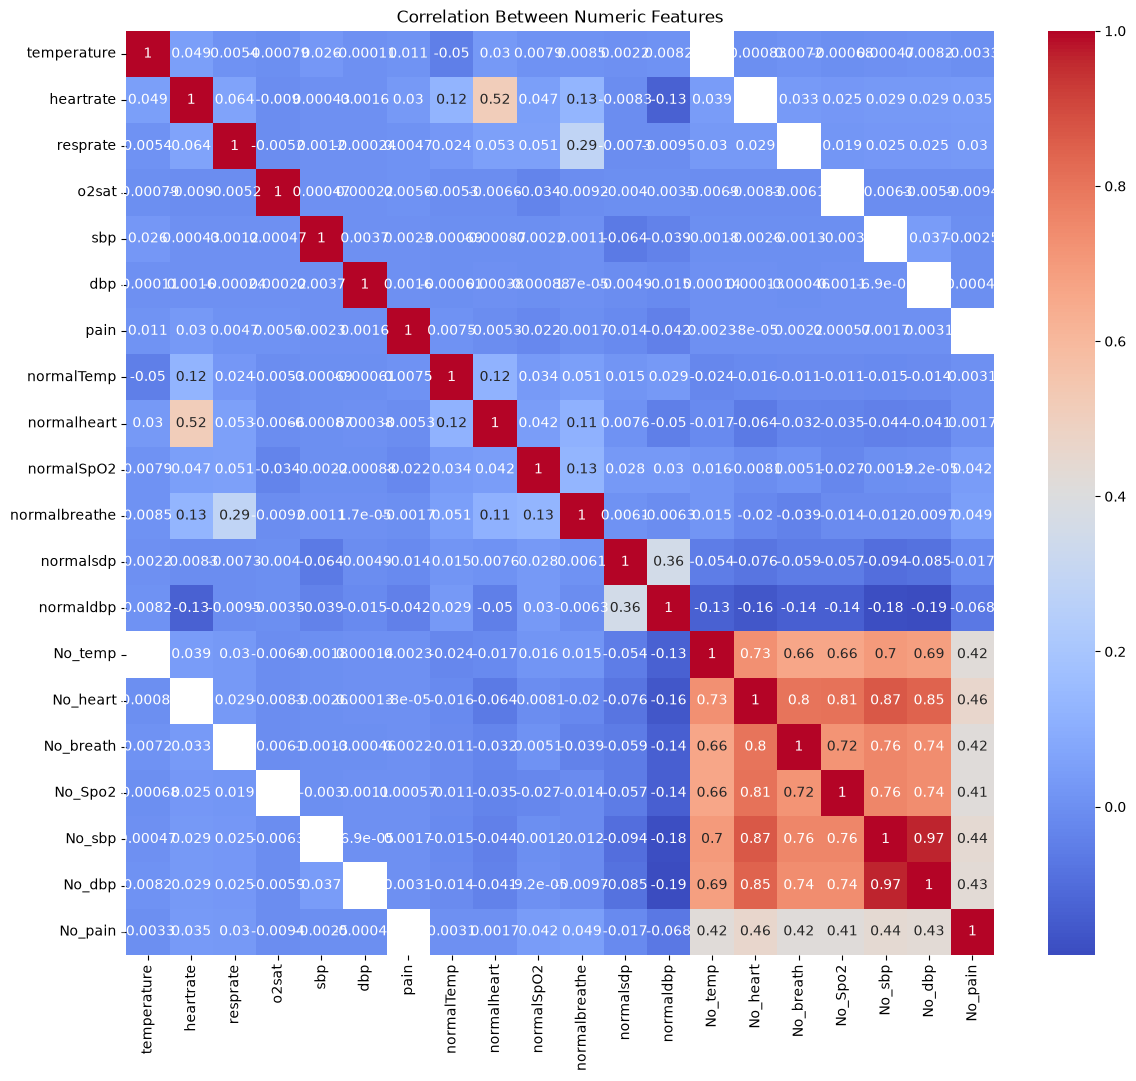

In [45]:
correlation_matrix = ed_triage[numeric_features].corr(method="pearson")

plt.figure(figsize=(14,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True, 

)

plt.title("Correlation Between Numeric Features")

plt.show()